In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler,
    MaxAbsScaler,
    RobustScaler
)

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
df = titanic.copy()

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [6]:
df.shape

(891, 15)

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [9]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(107)

In [13]:
df.drop_duplicates()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [14]:
df["sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [15]:
df["embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [16]:
df["age"].value_counts()

age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64

In [17]:
df["class"].value_counts

<bound method IndexOpsMixin.value_counts of 0       Third
1       First
2       Third
3       First
4       Third
        ...  
886    Second
887     First
888     Third
889     First
890     Third
Name: class, Length: 891, dtype: category
Categories (3, str): ['First', 'Second', 'Third']>

In [18]:
df.corr(numeric_only=True)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000


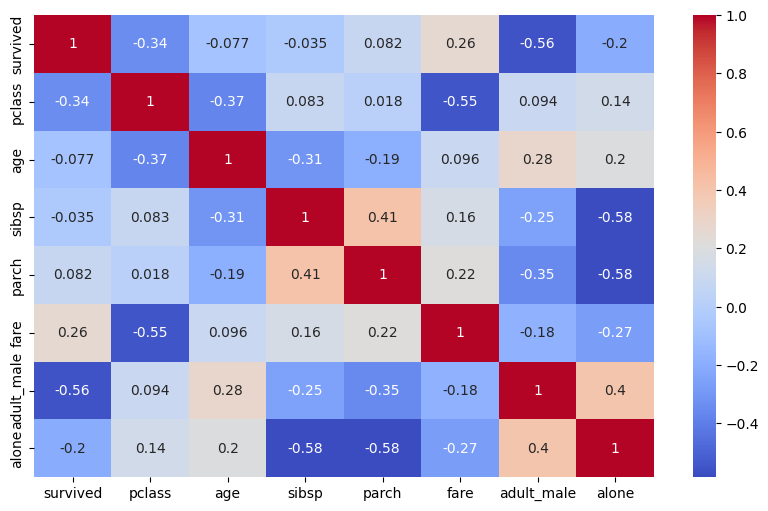

In [ ]:

plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

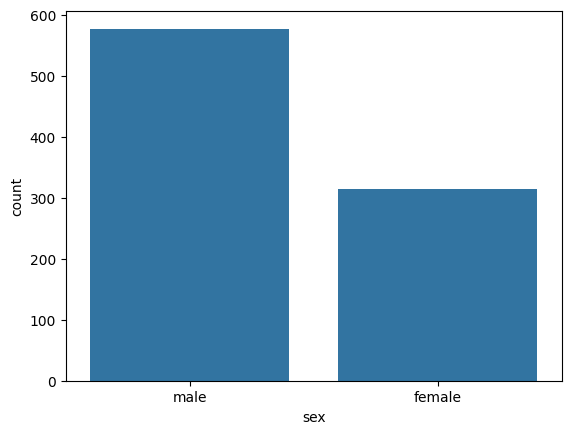

In [ ]:

sns.countplot(
    data=df,
    x="sex"
)
plt.show

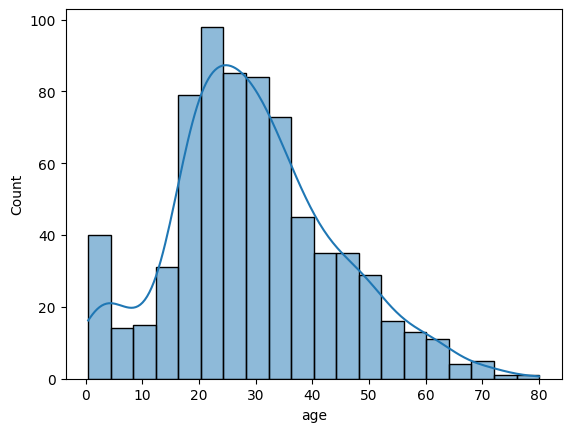

In [ ]:

sns.histplot(
    df["age"],
    kde=True
)
plt.show()

In [22]:
df.isnull().sum

<bound method DataFrame.sum of      survived  pclass    sex    age  sibsp  parch   fare  embarked  class  \
0       False   False  False  False  False  False  False     False  False   
1       False   False  False  False  False  False  False     False  False   
2       False   False  False  False  False  False  False     False  False   
3       False   False  False  False  False  False  False     False  False   
4       False   False  False  False  False  False  False     False  False   
..        ...     ...    ...    ...    ...    ...    ...       ...    ...   
886     False   False  False  False  False  False  False     False  False   
887     False   False  False  False  False  False  False     False  False   
888     False   False  False   True  False  False  False     False  False   
889     False   False  False  False  False  False  False     False  False   
890     False   False  False  False  False  False  False     False  False   

       who  adult_male   deck  embark_town  

In [23]:
(df.isnull().sum()/len(df))*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [24]:
df["age"] = df["age"].fillna(
    df["age"].median()
)

In [25]:
df["embarked"] = df["embarked"].fillna(
    df["embarked"].mode()[0]
)

In [26]:
df = df.drop(columns=["deck"])

In [27]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


In [28]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [29]:
first_part = df.iloc[400:]

In [30]:
second_part = df.iloc[400:]

In [31]:
new_df = pd.concat(
    [first_part,second_part],
    axis=0
)

new_df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
400,1,3,male,39.0,0,0,7.9250,S,Third,man,True,Southampton,yes,True
401,0,3,male,26.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
402,0,3,female,21.0,1,0,9.8250,S,Third,woman,False,Southampton,no,False
403,0,3,male,28.0,1,0,15.8500,S,Third,man,True,Southampton,no,False
404,0,3,female,20.0,0,0,8.6625,S,Third,woman,False,Southampton,no,True


In [32]:
# label encoding

In [33]:
le = LabelEncoder()
df["sex_label"] = le.fit_transform(
    df["sex"]
)

In [34]:
df[["sex","sex_label"]].head()

,sex,sex_label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [35]:
# ordinal encoding

In [36]:
df["priority"] = np.random.choice(
    ["Low","Medium","High"],
    size=len(df)
)

In [37]:
df["priority"].head()

0      High
1       Low
2      High
3    Medium
4       Low
Name: priority, dtype: str

In [38]:
oe = OrdinalEncoder(
    categories=[
        ["Low","Medium","High"]
    ]
)

df["priority_encoded"] = oe.fit_transform(
    df[["priority"]]
)

In [39]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_label,priority,priority_encoded
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1,High,2.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,0,Low,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0,High,2.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,0,Medium,1.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,Low,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True,1,Low,0.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True,0,Medium,1.0
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Southampton,no,False,0,Medium,1.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,1,Medium,1.0


In [40]:
df[
    [
        "priority",
        "priority_encoded"
    ]
].head()

,priority,priority_encoded
0,High,2.0
1,Low,0.0
2,High,2.0
3,Medium,1.0
4,Low,0.0


In [41]:
embarked_dummies = pd.get_dummies(
    df["embarked"],
    prefix="embarked"
)

In [42]:
embarked_dummies.head()

,embarked_C,embarked_Q,embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


In [43]:
df = pd.concat(
    [df, embarked_dummies],
    axis=1
)

In [44]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,sex_label,priority,priority_encoded,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,1,High,2.0,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,0,Low,0.0,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,0,High,2.0,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,0,Medium,1.0,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,Low,0.0,False,False,True


In [45]:
# min max scaler

In [46]:
minmax = MinMaxScaler()

In [47]:
df["age_minmax"] = minmax.fit_transform(
    df[["age"]]
)

In [48]:
df[
    [
        "age",
        "age_minmax"
    ]
].head()

,age,age_minmax
0,22.0,0.271174
1,38.0,0.472229
2,26.0,0.321438
3,35.0,0.434531
4,35.0,0.434531


In [49]:
# stanadrd scaler

In [50]:
std_sc = StandardScaler()

In [51]:
df["age"]= std_sc.fit_transform(df[["age"]])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,embark_town,alive,alone,sex_label,priority,priority_encoded,embarked_C,embarked_Q,embarked_S,age_minmax
0,0,3,male,-0.565736,1,0,7.2500,S,Third,man,...,Southampton,no,False,1,High,2.0,False,False,True,0.271174
1,1,1,female,0.663861,1,0,71.2833,C,First,woman,...,Cherbourg,yes,False,0,Low,0.0,True,False,False,0.472229
2,1,3,female,-0.258337,0,0,7.9250,S,Third,woman,...,Southampton,yes,True,0,High,2.0,False,False,True,0.321438
3,1,1,female,0.433312,1,0,53.1000,S,First,woman,...,Southampton,yes,False,0,Medium,1.0,False,False,True,0.434531
4,0,3,male,0.433312,0,0,8.0500,S,Third,man,...,Southampton,no,True,1,Low,0.0,False,False,True,0.434531


In [52]:
df["age"].std()

np.float64(1.0005616400330457)

In [53]:
df["age"].mean()

np.float64(2.272779794518839e-16)

In [54]:
df["age"].agg(
    ["mean", "median", "std", "min", "max"]
)

mean      2.272780e-16
median   -1.046374e-01
std       1.000562e+00
min      -2.224156e+00
max       3.891554e+00
Name: age, dtype: float64

In [55]:
# max abs scaler

In [56]:
maxabs = MaxAbsScaler()

In [57]:
df["fare_maxabs"] = maxabs.fit_transform(
    df[["fare"]]
)

In [58]:
df["fare"].agg(
    ["mean", "median", "std", "min", "max"]
)

mean       32.204208
median     14.454200
std        49.693429
min         0.000000
max       512.329200
Name: fare, dtype: float64

In [59]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,alive,alone,sex_label,priority,priority_encoded,embarked_C,embarked_Q,embarked_S,age_minmax,fare_maxabs
0,0,3,male,-0.565736,1,0,7.2500,S,Third,man,...,no,False,1,High,2.0,False,False,True,0.271174,0.014151
1,1,1,female,0.663861,1,0,71.2833,C,First,woman,...,yes,False,0,Low,0.0,True,False,False,0.472229,0.139136
2,1,3,female,-0.258337,0,0,7.9250,S,Third,woman,...,yes,True,0,High,2.0,False,False,True,0.321438,0.015469
3,1,1,female,0.433312,1,0,53.1000,S,First,woman,...,yes,False,0,Medium,1.0,False,False,True,0.434531,0.103644
4,0,3,male,0.433312,0,0,8.0500,S,Third,man,...,no,True,1,Low,0.0,False,False,True,0.434531,0.015713


In [60]:
df[
    [
        "fare",
        "fare_maxabs"
    ]
].head()

,fare,fare_maxabs
0,7.2500,0.014151
1,71.2833,0.139136
2,7.9250,0.015469
3,53.1000,0.103644
4,8.0500,0.015713


In [61]:
# robust scaler

In [62]:
robust = RobustScaler()

In [63]:
df["fare_robust"] = robust.fit_transform(
    df[["fare"]]
)

In [64]:
df["fare"].agg(
    ["mean", "median", "std", "min", "max"]
)

mean       32.204208
median     14.454200
std        49.693429
min         0.000000
max       512.329200
Name: fare, dtype: float64

In [65]:
df[
    [
        "fare",
        "fare_robust"
    ]
].head()

,fare,fare_robust
0,7.2500,-0.312011
1,71.2833,2.461242
2,7.9250,-0.282777
3,53.1000,1.673732
4,8.0500,-0.277363


In [66]:
from pandas.api.types import is_numeric_dtype



In [67]:

from sklearn.preprocessing import FunctionTransformer
from pandas.api.types import is_numeric_dtype
import numpy as np

log_transform = FunctionTransformer(np.log1p)

In [68]:
for col in df.columns:
    if is_numeric_dtype(df[col]):
        if (df[col] >= 0).all():
            df[col] = log_transform.fit_transform(df[[col]])

In [69]:
df.head()

c:\Users\ASUS\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,alone,sex_label,priority,priority_encoded,embarked_C,embarked_Q,embarked_S,age_minmax,fare_maxabs,fare_robust
0,0.000000,1.386294,male,-0.565736,0.693147,0.0,2.110213,S,Third,man,...,0.000000,0.693147,High,1.098612,0.000000,0.0,0.693359,0.239941,0.014052,-0.312011
1,0.693147,0.693147,female,0.663861,0.693147,0.0,4.280593,C,First,woman,...,0.000000,0.000000,Low,0.000000,0.693359,0.0,0.000000,0.386778,0.130270,2.461242
2,0.693147,1.386294,female,-0.258337,0.000000,0.0,2.188856,S,Third,woman,...,0.693359,0.000000,High,1.098612,0.000000,0.0,0.693359,0.278720,0.015350,-0.282777
3,0.693147,0.693147,female,0.433312,0.693147,0.0,3.990834,S,First,woman,...,0.000000,0.000000,Medium,0.693147,0.000000,0.0,0.693359,0.360838,0.098618,1.673732
4,0.000000,1.386294,male,0.433312,0.000000,0.0,2.202765,S,Third,man,...,0.693359,0.693147,Low,0.000000,0.000000,0.0,0.693359,0.360838,0.015590,-0.277363


In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   survived          891 non-null    float64 
 1   pclass            891 non-null    float64 
 2   sex               891 non-null    str     
 3   age               891 non-null    float64 
 4   sibsp             891 non-null    float64 
 5   parch             891 non-null    float64 
 6   fare              891 non-null    float64 
 7   embarked          891 non-null    str     
 8   class             891 non-null    category
 9   who               891 non-null    str     
 10  adult_male        891 non-null    float16 
 11  embark_town       889 non-null    str     
 12  alive             891 non-null    str     
 13  alone             891 non-null    float16 
 14  sex_label         891 non-null    float64 
 15  priority          891 non-null    str     
 16  priority_encoded  891 non-null    flo

In [71]:
df.to_csv(
    "titanic_Preprocessed.csv",
    index=False
)